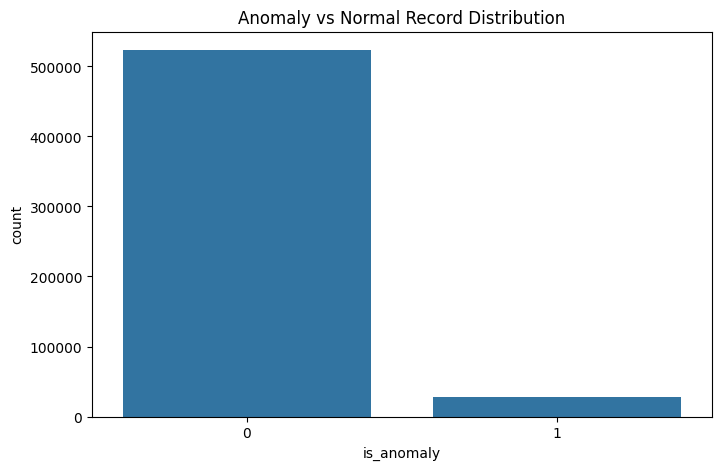

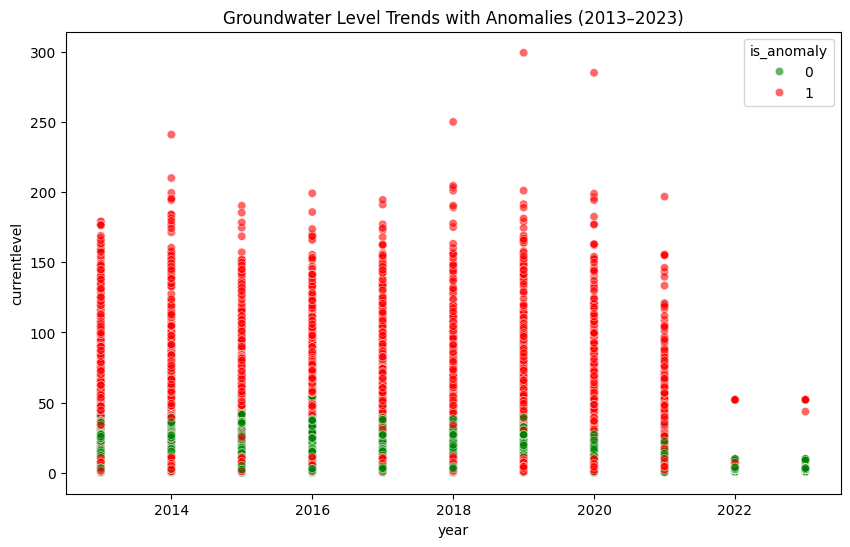

✅ Anomaly detection completed and saved successfully.


In [ ]:
# Author: Aaryan Tamhane | ML CA Project | 2025

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
import joblib

# 2️⃣ Load Dataset
df = pd.read_csv("/content/22070521127_ML_clean.csv")

# 3️⃣ Select Relevant Features
features = ['year', 'state_name', 'district_name', 'latitude', 'longitude', 'currentlevel', 'level_diff']
data = df[features].copy()

# 4️⃣ Encode Categorical Columns
encoder = LabelEncoder()
for col in ['state_name', 'district_name']:
    data[col] = encoder.fit_transform(data[col].astype(str))

# 5️⃣ Handle Missing Values (if any)
data = data.fillna(data.median(numeric_only=True))

# 6️⃣ Scale Numerical Features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 7️⃣ Isolation Forest Model
iso = IsolationForest(contamination=0.05, random_state=42)
data['anomaly_score'] = iso.fit_predict(scaled_data)

# 8️⃣ Mark Anomalies (1 = anomaly, 0 = normal)
data['is_anomaly'] = np.where(data['anomaly_score'] == -1, 1, 0)

# 9️⃣ Merge back with Original Data
df['is_anomaly'] = data['is_anomaly']

# 🔟 Visualization
plt.figure(figsize=(8,5))
sns.countplot(x='is_anomaly', data=df)
plt.title("Anomaly vs Normal Record Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='year', y='currentlevel', hue='is_anomaly', palette=['green','red'], data=df, alpha=0.6)
plt.title("Groundwater Level Trends with Anomalies (2013–2023)")
plt.show()

# 11️⃣ Save Model and Data
df.to_csv("groundwater_anomalies.csv", index=False)
joblib.dump(iso, "anomaly_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Anomaly detection completed and saved successfully.")


In [ ]:
# --- District-wise Anomaly Statistics ---

import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import plotly.express as px

# Group by district to calculate total & anomalous records
district_anomaly_stats = (
    df.groupby('district_name')['is_anomaly']
    .agg(['count', 'sum'])
    .reset_index()
    .rename(columns={'count': 'total_records', 'sum': 'anomaly_count'})
)

# Calculate anomaly percentage
district_anomaly_stats['anomaly_percentage'] = (
    district_anomaly_stats['anomaly_count'] / district_anomaly_stats['total_records'] * 100
).round(2)

# Sort districts by anomaly percentage
district_anomaly_stats = district_anomaly_stats.sort_values(
    by='anomaly_percentage', ascending=False
)

print("✅ Top 10 Districts with Highest Anomaly Percentage:")
print(district_anomaly_stats.head(10))

# --- Bar Plot of Top 10 Districts ---
plt.figure(figsize=(12, 6))
top10 = district_anomaly_stats.head(10)
plt.barh(top10['district_name'], top10['anomaly_percentage'], color='tomato')
plt.xlabel("Anomaly Percentage (%)")
plt.ylabel("District")
plt.title("Top 10 Districts with Highest Groundwater Anomaly Percentage (2013–2023)")
plt.gca().invert_yaxis()
plt.show()

# --- Optional: India District Map Visualization (Requires internet access in Colab) ---

# Load India administrative boundaries (GeoJSON)
url = "https://raw.githubusercontent.com/geohacker/india/master/district/india_district.geojson"
india_districts = gpd.read_file(url)

# Inspect the column names of the GeoDataFrame to find the correct district name column
print("Column names in india_districts GeoDataFrame:")
print(india_districts.columns)

# Merge anomaly stats with spatial data
# Assuming the district name column in the geojson is 'NAME_2' based on common conventions for this dataset
india_districts = india_districts.merge(
    district_anomaly_stats,
    left_on='NAME_2', right_on='district_name',
    how='left'
)

# Interactive choropleth map using Plotly
fig = px.choropleth(
    india_districts,
    geojson=india_districts.geometry,
    locations=india_districts.index,
    color='anomaly_percentage',
    hover_name='district_name',
    hover_data=['anomaly_count', 'total_records'],
    color_continuous_scale="Reds",
    title="Groundwater Anomaly Percentage by District (2013–2023)"
)
fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import joblib

# Load your clean dataset
df = pd.read_csv("22070521127_ML_clean.csv")

# ✅ Use only columns that actually exist in your dataset
features = ["currentlevel", "level_diff", "latitude", "longitude", "year"]

# Filter the dataset
X = df[features].dropna()

# ✅ Train Isolation Forest
anomaly_model = IsolationForest(contamination=0.05, random_state=42)
anomaly_model.fit(X)

# ✅ Save model
joblib.dump(anomaly_model, "anomaly_model.pkl")
print("✅ New anomaly model trained and saved successfully with features:", features)


✅ New anomaly model trained and saved successfully with features: ['currentlevel', 'level_diff', 'latitude', 'longitude', 'year']


In [ ]:
from google.colab import files
files.download("anomaly_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>